In [32]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict , Annotated
from pydantic import BaseModel , Field
from dotenv import load_dotenv
import operator
load_dotenv()

True

In [33]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [34]:
class EvaluationSchema(BaseModel):
    feedback : str = Field(description='Detailed feedback for the query')
    score : int = Field(description='Score out of 10' , ge=0 , le=10)

structured_model = model.with_structured_output(EvaluationSchema)

In [ ]:
class UPSCState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_score : Annotated[list[int] , operator.add] # Annotated allows adding extra metadata/instructions to a type hint
    avg_score : float

## Real meaning of Reducer
## operator.add here is called a:
## Reducer
## A reducer tells LangGraph:
## "When many nodes update same state key, how should values combine?"

In [36]:
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate quality of language and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {'language_feedback':output.feedback , 'individual_score':[output.score]}

In [37]:
def evaluate_thought(state: UPSCState):
    prompt = f"Evaluate quality of thought and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {'clarity_feedback':output.feedback , 'individual_score':[output.score]}

In [38]:
def evaluate_analysis(state: UPSCState):
    prompt = f"Analyse the essay and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {'analysis_feedback':output.feedback , 'individual_score':[output.score]}

In [39]:
def final_evaluate(state: UPSCState):
    prompt = f"Based of the following feedback create a summarized feedback \n language_feedback - {state['language_feedback']} \n analysis_feedback - {state['analysis_feedback']} \n clarity_feedback -{state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    return {'overall_feedback':overall_feedback , 'avg_score':avg_score}

In [40]:
graph = StateGraph(UPSCState)
graph.add_node('evaluate_language' , evaluate_language)
graph.add_node('evaluate_thought' , evaluate_thought)
graph.add_node('evaluate_analysis' , evaluate_analysis)
graph.add_node('final_evaluate' , final_evaluate)

In [41]:
graph.add_edge(START , 'evaluate_language')
graph.add_edge(START , 'evaluate_analysis')
graph.add_edge(START , 'evaluate_thought')

graph.add_edge('evaluate_language' , 'final_evaluate')
graph.add_edge('evaluate_thought' , 'final_evaluate')
graph.add_edge('evaluate_analysis' , 'final_evaluate')

graph.add_edge('final_evaluate' , END)

In [42]:
workflow = graph.compile()
print(workflow.invoke({'essay':"""## Essay on Republic Day

Republic Day is one of the most important national festivals of India. It is celebrated every year on 26th January with great pride and enthusiasm. On this day in 1950, the Constitution of India came into effect, and India became a republic nation. Dr. B. R. Ambedkar played a major role in drafting the Constitution.

Republic Day reminds us of the sacrifices made by freedom fighters for the independence of our country. It is celebrated all over India in schools, colleges, and government institutions. Students participate in cultural programs, speeches, dances, and patriotic songs. The national flag is hoisted, and sweets are distributed among students.

A grand parade is organized in New Delhi at Kartavya Path. The parade showcases the strength of the Indian Army, Navy, and Air Force. Different states also present colorful tableaux displaying their culture and traditions. The President of India hoists the national flag and gives awards to brave soldiers and citizens.

Republic Day teaches us the values of unity, democracy, and patriotism. It inspires every citizen to respect the Constitution and work for the progress of the nation. We should always be proud to be Indians and contribute towards making our country strong and developed.

**Jai Hind!**
"""}))

{'essay': '## Essay on Republic Day\n\nRepublic Day is one of the most important national festivals of India. It is celebrated every year on 26th January with great pride and enthusiasm. On this day in 1950, the Constitution of India came into effect, and India became a republic nation. Dr. B. R. Ambedkar played a major role in drafting the Constitution.\n\nRepublic Day reminds us of the sacrifices made by freedom fighters for the independence of our country. It is celebrated all over India in schools, colleges, and government institutions. Students participate in cultural programs, speeches, dances, and patriotic songs. The national flag is hoisted, and sweets are distributed among students.\n\nA grand parade is organized in New Delhi at Kartavya Path. The parade showcases the strength of the Indian Army, Navy, and Air Force. Different states also present colorful tableaux displaying their culture and traditions. The President of India hoists the national flag and gives awards to brav

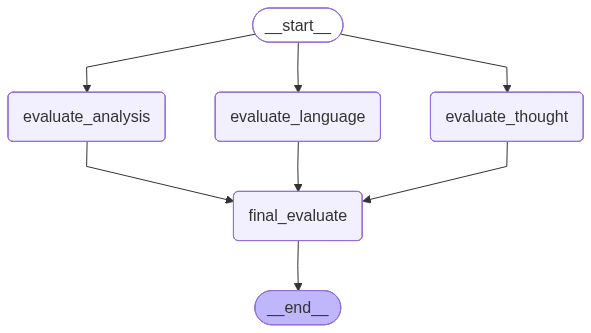

In [43]:
from IPython.display import Image
workflow = graph.compile()
Image(workflow.get_graph().draw_mermaid_png())